# MassMIND Segmentation — Colab Training

Runs the U-Net + VGG-16 baseline on a Colab GPU for each of the three augmentation pipelines (A, B, C) and produces a comparison of their training curves and final per-class IoU.

**Prerequisites**

1. **GPU runtime**: Runtime → Change runtime type → T4 GPU (or better).
2. **Private repo access**: have a GitHub Personal Access Token with `repo` scope ready (github.com → Settings → Developer Settings → Personal access tokens). You'll be prompted for it in the clone cell — it never gets written to disk or the notebook output.
3. **(Optional) Google Drive**: if you want checkpoints to survive the session ending, run the optional Drive-mount cell below.

**Expected runtime**: ~30–60 min per config on a T4 (30 epochs × 2042 images). All three configs back-to-back fit comfortably inside Colab's free 12-hour session limit.

## 0. Config

Edit this cell to change which configs to run, epochs, batch size, etc.

In [2]:
REPO_URL_HTTPS = 'https://github.com/whothemann/massmind-segmentation.git'  # <-- EDIT ME
REPO_BRANCH = 'main'
REPO_DIR = 'massmind-segmentation'

# Training
EPOCHS = 20         # 30 if you have time -- 20 fits comfortably in one Colab session
BATCH_SIZE = 16     # T4 has 16 GB; this batch size keeps GPU well-utilized
LR = 1e-4

# Persistence (optional). Set both to None to keep everything in the ephemeral runtime.
# NOTE: writes only work under /content/drive/MyDrive/... ; /content/drive itself is read-only.
DRIVE_RUNS_DIR = None   # e.g. '/content/drive/MyDrive/massmind_runs'
DRIVE_HF_CACHE = None   # e.g. '/content/drive/MyDrive/hf_cache' -- avoids re-downloading VGG-16 weights

## 1. Clone the repository

You'll be prompted for a GitHub Personal Access Token. The token is read via `getpass` so it does not get echoed or saved into the notebook output.

In [3]:
import os
import getpass
import subprocess
from pathlib import Path

if Path(REPO_DIR).exists():
    print(f'{REPO_DIR} already present — pulling latest from {REPO_BRANCH}')
    subprocess.run(['git', '-C', REPO_DIR, 'fetch', 'origin'], check=True)
    subprocess.run(['git', '-C', REPO_DIR, 'checkout', REPO_BRANCH], check=True)
    subprocess.run(['git', '-C', REPO_DIR, 'pull', '--ff-only'], check=True)
else:
    token = getpass.getpass('GitHub PAT (repo scope): ').strip()
    if not token:
        raise RuntimeError('No token provided.')
    # Inject the token into the HTTPS URL only for this single git operation.
    auth_url = REPO_URL_HTTPS.replace('https://', f'https://x-access-token:{token}@')
    subprocess.run(['git', 'clone', '-b', REPO_BRANCH, auth_url, REPO_DIR], check=True)
    # Rewrite the remote without the token so it isn't stored in .git/config.
    subprocess.run(['git', '-C', REPO_DIR, 'remote', 'set-url', 'origin', REPO_URL_HTTPS], check=True)
    del token, auth_url

os.chdir(REPO_DIR)
print('cwd:', os.getcwd())

GitHub PAT (repo scope):  ········


Cloning into 'massmind-segmentation'...


cwd: /kaggle/working/massmind-segmentation


## 2. Install dependencies

Colab T4 ships with a recent torch + CUDA stack pre-installed, so this step mostly pulls albumentations / smp / gdown / opencv-headless. ~1–2 minutes.

In [4]:
!pip install -q -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 88.8 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.9/261.9 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.7/53.7 kB 3.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jupyterlab-lsp 3.10.2 requires jupyterlab<4.0.0a0,>=3.1.0, but you have jupyterlab 4.5.7 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


## 3. GPU sanity check

In [5]:
import torch
print('torch        :', torch.__version__)
print('cuda available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('device       :', torch.cuda.get_device_name(0))
    print('vram (GB)    :', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1))
!nvidia-smi --query-gpu=name,memory.total,memory.used,driver_version --format=csv

torch        : 2.10.0+cu128
cuda available: True
device       : Tesla T4
vram (GB)    : 15.6
name, memory.total [MiB], memory.used [MiB], driver_version
Tesla T4, 15360 MiB, 3 MiB, 580.105.08
Tesla T4, 15360 MiB, 3 MiB, 580.105.08


## 4. (Optional) Mount Google Drive for persistence

If `DRIVE_RUNS_DIR` is set in the config cell, run this to mount Drive and redirect run outputs + HuggingFace cache there. Otherwise everything lives in the ephemeral Colab runtime — fine for one session, gone on disconnect.

In [6]:
if DRIVE_RUNS_DIR or DRIVE_HF_CACHE:
    from google.colab import drive
    drive.mount('/content/drive')
    if DRIVE_RUNS_DIR:
        Path(DRIVE_RUNS_DIR).mkdir(parents=True, exist_ok=True)
        print('Run outputs will be saved under:', DRIVE_RUNS_DIR)
    if DRIVE_HF_CACHE:
        Path(DRIVE_HF_CACHE).mkdir(parents=True, exist_ok=True)
        os.environ['HF_HOME'] = DRIVE_HF_CACHE
        print('HF cache redirected to:', DRIVE_HF_CACHE)
else:
    print('No Drive paths set — running ephemerally.')

No Drive paths set — running ephemerally.


## 5. Download dataset and prepare splits + stats

Idempotent — re-running just verifies the files are present. ~1–2 min the first time (Google Drive download).

In [7]:
!python scripts/download.py
!python -m src.splits
!python -m src.stats

2026-05-12 18:38:22,411 INFO __main__: Downloading drive id=1T572f0oqy5JmuTvVEwkSUeXLWOSHl4hL -> /kaggle/working/massmind-segmentation/data/massmind/_archives/images.zip
Downloading...
From (original): https://drive.google.com/uc?id=1T572f0oqy5JmuTvVEwkSUeXLWOSHl4hL
From (redirected): https://drive.google.com/uc?id=1T572f0oqy5JmuTvVEwkSUeXLWOSHl4hL&confirm=t&uuid=141a5597-9118-4d73-8605-77ce2b6620e4
To: /kaggle/working/massmind-segmentation/data/massmind/_archives/images.zip
100%|████████████████████████████████████████| 434M/434M [00:05<00:00, 73.5MB/s]
2026-05-12 18:38:29,689 INFO __main__: Downloading drive id=1pHp480_Q-s72RoDf1nD7ERzsv9yZTDE1 -> /kaggle/working/massmind-segmentation/data/massmind/_archives/masks.zip
Downloading...
From: https://drive.google.com/uc?id=1pHp480_Q-s72RoDf1nD7ERzsv9yZTDE1
To: /kaggle/working/massmind-segmentation/data/massmind/_archives/masks.zip
100%|███████████████████████████████████████| 7.25M/7.25M [00:00<00:00, 123MB/s]
2026-05-12 18:38:32,372 INF

## 6. Train

Runs are split into three separate cells (A, B, C) so you can monitor each one independently and re-run a single config without redoing the others. The helper cell below defines `run_training(aug)`, which:

- streams the trainer's stdout line by line,
- shows a `tqdm` progress bar with the current / total epoch,
- updates a live loss + mIoU plot at the end of each epoch.

Each run dumps `runs/unet_vgg16_aug<X>_<ts>/` with checkpoints, `metrics.csv`, and `config.json`. If `DRIVE_RUNS_DIR` is set, the run directory is also copied to Drive after the run completes.

In [8]:
import re
import shutil
import subprocess
import time
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display
from tqdm.notebook import tqdm

# Will be populated by the per-augmentation cells below.
run_dirs = {}

# Matches the per-epoch log line emitted by src.train, e.g.:
#   epoch 12/30  train_loss=0.4321  val_loss=0.3987  mIoU=0.6541  pixel_acc=0.8123  (45.3s)
_EPOCH_RE = re.compile(
    r"epoch\s+(\d+)/(\d+)\s+train_loss=([\d.eE+-]+)\s+val_loss=([\d.eE+-]+)\s+mIoU=([\d.eE+-]+)"
)

# Colab free T4 only has 2 vCPUs; the trainer's CUDA default is 4 and
# oversubscribes, slowing dataloading. Match it to the actual core count.
NUM_WORKERS = 2


def _sync_to_drive(out_dir):
    """Copy the run dir to Drive (idempotent). Swallow errors so the run continues."""
    if not DRIVE_RUNS_DIR:
        return
    drive_path = Path(DRIVE_RUNS_DIR) / Path(out_dir).name
    try:
        shutil.copytree(out_dir, drive_path, dirs_exist_ok=True)
    except Exception as e:
        print(f"  [drive sync failed: {e}]")


def run_training(aug, loss="ce", focal_gamma=2.0, focal_alpha=None):
    """Launch src.train for one augmentation with a live progress bar + plot.

    Returns the output directory path on success, or raises on non-zero exit.
    Syncs the run dir to Drive after every completed epoch (when DRIVE_RUNS_DIR
    is set) so a runtime crash leaves the latest checkpoint + metrics behind.
    """
    # Defensive: kill any leftover trainer from a previous session that's still
    # holding GPU memory.
    subprocess.run(["pkill", "-9", "-f", "src.train"], check=False)

    ts = int(time.time())
    out_dir = f"runs/unet_vgg16_aug{aug}_{loss}_{ts}"
    print(f"=== Training aug={aug} loss={loss} -> {out_dir} ===")

    cmd = [
        "python", "-u", "-m", "src.train",
        "--augmentation", aug,
        "--epochs", str(EPOCHS),
        "--batch-size", str(BATCH_SIZE),
        "--lr", str(LR),
        "--num-workers", str(NUM_WORKERS),
        "--output-dir", out_dir,
        "--loss", loss,
    ]
    if loss == "focal":
        cmd += ["--focal-gamma", str(focal_gamma)]
        if focal_alpha is not None:
            cmd += ["--focal-alpha", str(focal_alpha)]

    pbar = tqdm(total=EPOCHS, desc=f"aug {aug}", unit="epoch")
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    plot_handle = display(fig, display_id=True)
    epochs, tloss, vloss, mious = [], [], [], []

    proc = subprocess.Popen(
        cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1
    )
    try:
        for raw in proc.stdout:
            line = raw.rstrip()
            print(line)
            m = _EPOCH_RE.search(line)
            if not m:
                continue
            ep, total = int(m.group(1)), int(m.group(2))
            tl, vl, mi = float(m.group(3)), float(m.group(4)), float(m.group(5))
            epochs.append(ep); tloss.append(tl); vloss.append(vl); mious.append(mi)
            pbar.total = total
            pbar.update(ep - pbar.n)

            axes[0].clear(); axes[1].clear()
            axes[0].plot(epochs, tloss, label="train", marker="o", markersize=3)
            axes[0].plot(epochs, vloss, label="val",   marker="o", markersize=3)
            axes[0].set_title(f"aug {aug} -- loss"); axes[0].set_xlabel("epoch")
            axes[0].set_ylabel("CE loss"); axes[0].legend(); axes[0].grid(alpha=0.3)
            axes[1].plot(epochs, mious, color="C2", marker="o", markersize=3)
            axes[1].set_title(f"aug {aug} -- val mIoU"); axes[1].set_xlabel("epoch")
            axes[1].set_ylabel("mIoU"); axes[1].grid(alpha=0.3)
            fig.tight_layout()
            plot_handle.update(fig)

            # Persist after each epoch so a crash doesn't wipe progress.
            _sync_to_drive(out_dir)
    except KeyboardInterrupt:
        proc.terminate()
        raise
    finally:
        proc.wait()
        pbar.close()
        plt.close(fig)

    if proc.returncode != 0:
        raise RuntimeError(f"Training for aug {aug} exited with code {proc.returncode}")

    _sync_to_drive(out_dir)  # final sync (idempotent)
    if DRIVE_RUNS_DIR:
        print(f"Copied to Drive: {Path(DRIVE_RUNS_DIR) / Path(out_dir).name}")

    return out_dir

In [9]:
# Browser-side keepalive: simulates a periodic click on the Colab connect
# button so the runtime registers ongoing activity and skips the ~90 min idle
# disconnect. Run once after the helper is defined; safe to leave running.
from IPython.display import Javascript, display
display(Javascript('''
setInterval(() => {
    const btn = document.querySelector("colab-connect-button");
    if (btn) btn.click();
}, 60000);
console.log("Colab keepalive started (60s ping).");
'''))

<IPython.core.display.Javascript object>

### 6a. Focal loss + Augmentation A

Focal loss (gamma=2.0, alpha=None) with the MassMIND-replicated geometric augmentation. Focal down-weights confident pixels (sky, water) so the gradient is dominated by the rare-class pixels (obstacle, living_obs) that cross-entropy keeps drowning out. First training run of the section -- compare its curves against the cross-entropy + Aug A run in 6b.

=== Training aug=A loss=focal -> runs/unet_vgg16_augA_focal_1778611126 ===


aug A:   0%|          | 0/20 [00:00<?, ?epoch/s]

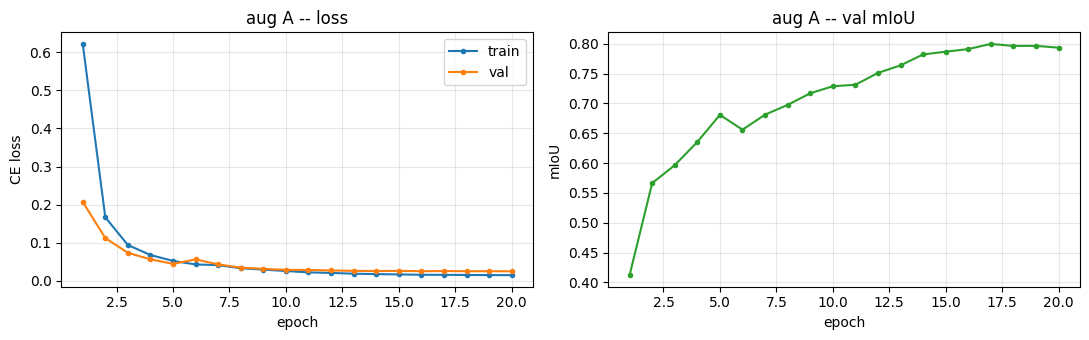

2026-05-12 18:39:00,485 INFO __main__: Device: cuda
2026-05-12 18:39:00,489 INFO __main__: train batches=128 (n=2042)  val batches=37 (n=583)  norm: mean=0.5067 std=0.1960
2026-05-12 18:39:02,557 INFO httpx: HTTP Request: HEAD https://huggingface.co/smp-hub/vgg16.imagenet/resolve/49d74b799006ee252b86e25acd6f1fd8ac9a99c1/config.json "HTTP/1.1 307 Temporary Redirect"
2026-05-12 18:39:02,558 WARNING huggingface_hub.utils._http: Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-05-12 18:39:02,574 INFO httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/smp-hub/vgg16.imagenet/49d74b799006ee252b86e25acd6f1fd8ac9a99c1/config.json "HTTP/1.1 200 OK"
2026-05-12 18:39:02,591 INFO httpx: HTTP Request: GET https://huggingface.co/api/resolve-cache/models/smp-hub/vgg16.imagenet/49d74b799006ee252b86e25acd6f1fd8ac9a99c1/config.json "HTTP/1.1 200 OK"
2026-05-12 18:39:02,647 INFO httpx: HTTP

In [10]:
run_dirs['focal_A'] = run_training('A', loss='focal')

### 6b. Augmentation A (cross-entropy)

Pipeline A: geometric augmentations only (random flip, scale, crop). Train and watch progress.

In [11]:
#run_dirs['A'] = run_training('A')

### 6c. Augmentation B (cross-entropy)

Pipeline B: geometric + photometric augmentations. Train and watch progress.

In [12]:
#run_dirs['B'] = run_training('B')

### 6d. Augmentation C (cross-entropy)

Pipeline C: minimal augmentations (normalization only). Train and watch progress.

In [13]:
#run_dirs['C'] = run_training('C')

## 7. Compare runs

Loads `metrics.csv` for each completed run and overlays train/val loss + mIoU curves, plus a final per-class IoU table.

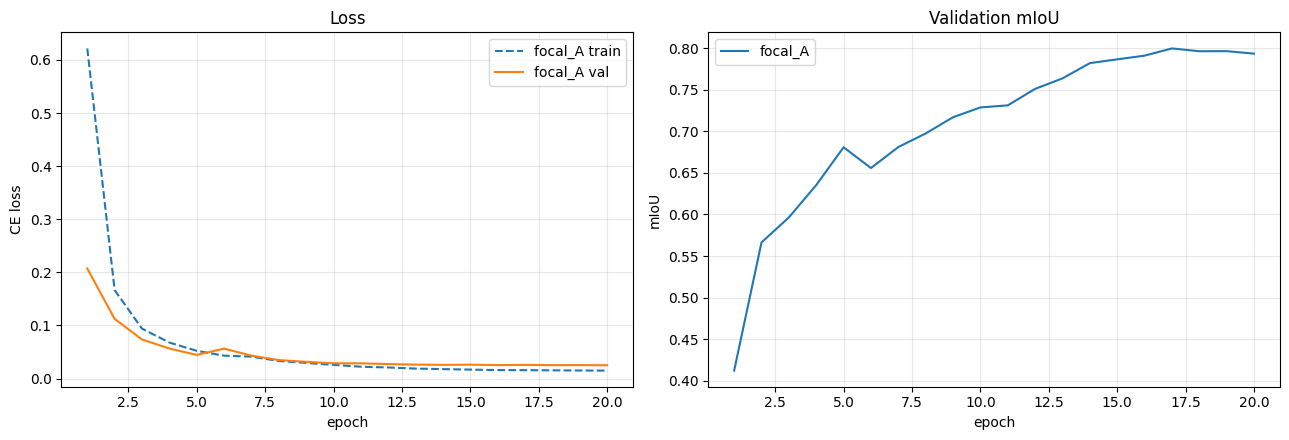

In [14]:
import json
import pandas as pd
import matplotlib.pyplot as plt

metrics = {aug: pd.read_csv(Path(d) / 'metrics.csv') for aug, d in run_dirs.items()}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for aug, df in metrics.items():
    axes[0].plot(df['epoch'], df['train_loss'], label=f'{aug} train', linestyle='--')
    axes[0].plot(df['epoch'], df['val_loss'],   label=f'{aug} val')
    axes[1].plot(df['epoch'], df['mIoU'],       label=f'{aug}')
axes[0].set_title('Loss'); axes[0].set_xlabel('epoch'); axes[0].set_ylabel('CE loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title('Validation mIoU'); axes[1].set_xlabel('epoch'); axes[1].set_ylabel('mIoU'); axes[1].legend(); axes[1].grid(alpha=0.3)
fig.tight_layout()

In [15]:
CLASS_NAMES = ['sky', 'water', 'bridge', 'obstacle', 'living_obs', 'background', 'self']
rows = []
for aug, df in metrics.items():
    # Pick the row with best val mIoU.
    best = df.loc[df['mIoU'].idxmax()]
    row = {'aug': aug, 'best_epoch': int(best['epoch']), 'mIoU': best['mIoU'], 'pixel_acc': best['pixel_acc']}
    for n in CLASS_NAMES:
        row[f'iou_{n}'] = best[f'iou_{n}']
    rows.append(row)
summary = pd.DataFrame(rows).set_index('aug')
summary

,best_epoch,mIoU,pixel_acc,iou_sky,iou_water,iou_bridge,iou_obstacle,iou_living_obs,iou_background,iou_self
aug,,,,,,,,,,
focal_A,17,0.79978,0.98296,0.9848,0.9898,0.72034,0.65558,0.41299,0.89235,0.94258


## 8. Push run outputs back to the repo (optional)

If you want `metrics.csv` + `config.json` in the repo for reproducibility (without committing the heavy `.pt` checkpoints), uncomment and run. The `.gitignore` already excludes `runs/`, so we have to add the metrics files explicitly with `git add -f`.

In [16]:
# COMMIT_RESULTS = False
# if COMMIT_RESULTS:
#     for aug, d in run_dirs.items():
#         !git add -f {d}/metrics.csv {d}/config.json
#     !git -c user.email='colab@local' -c user.name='colab' commit -m 'add training metrics from Colab run'
#     # You will need to push manually with a PAT — see the clone cell pattern.